# Titanic Learning Lab: Supervised vs Unsupervised
### Goal: Compare Logistic Regression (Supervised) vs K-Means (Unsupervised)

**Name of Student:** Vishnu Thangaraj  
**Roll Number:** 845488

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 1. Load Titanic dataset
titanic = pd.read_csv("../Dataset/titanic.csv")

## Part 1: Supervised Learning
Predict survival using Logistic Regression

In [2]:
# Predict survival using Logistic Regression
# Select features and target 
X = titanic[['Age', 'Pclass', 'Sex']].copy()
y = titanic['Survived']

# Handle missing values
X['Age'] = X['Age'].fillna(X['Age'].mean())
# Encode categorical variable
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train model
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)
# Predict
y_pred = log_model.predict(X_test)
# Evaluate
print("Supervised Learning (Logistic Regression)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Supervised Learning (Logistic Regression)
Accuracy: 0.8100558659217877
Confusion Matrix:
 [[91 14]
 [20 54]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## Part 2: Unsupervised Learning
Group passengers using K-Means clustering


Unsupervised Learning (K-Means Clustering)
Cluster Centers:
 [[ 28.63774227  15.45395432   2.55144033]
 [ 31.01991176 279.308545     1.        ]
 [ 34.96198219  83.39327958   1.24647887]]


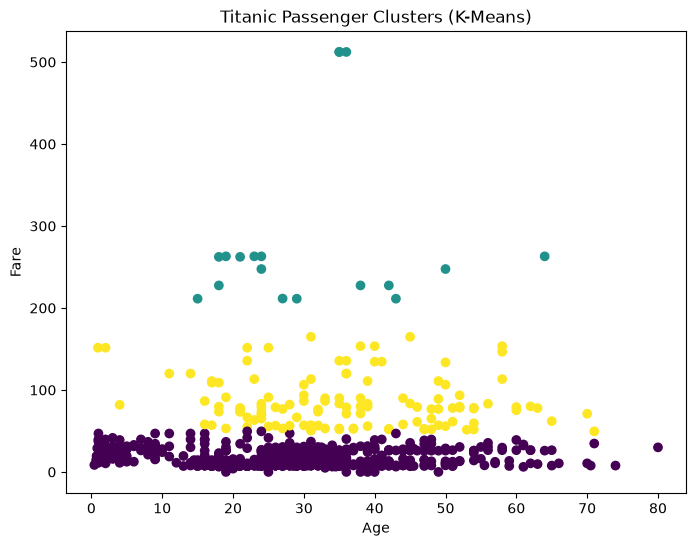

In [3]:
# Group passengers using K-Means clustering
# Select features for clustering
X_cluster = titanic[['Age', 'Fare', 'Pclass']].fillna(titanic[['Age', 'Fare', 'Pclass']].mean())
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
titanic['Cluster'] = kmeans.fit_predict(X_cluster)
# Show cluster centers
print("\nUnsupervised Learning (K-Means Clustering)")
print("Cluster Centers:\n", kmeans.cluster_centers_)
# Visualize clusters
plt.figure(figsize=(8, 6))
plt.scatter(titanic['Age'], titanic['Fare'], c=titanic['Cluster'], cmap='viridis')
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Titanic Passenger Clusters (K-Means)")
plt.show()